# Latent geometry, capacity and stability (axis-100-3000)

How many of the ten latent dimensions the model uses, how that compares with the dimension of the input data, whether the structure is the same on held-out images, whether repetitions learn the same geometry and how sensitive the encoder is to input perturbations.

## Introduction

The latent code has ten dimensions on both axes although the wide axis has four times more bins. Capacity is
judged by comparing the latent's dimension usage with the dimension of the inputs themselves: a latent whose
effective dimension approaches its ambient dimension while the data require more is saturated. The
canonicalized code $U$ removes the LayerNorm affine map, so geometry is measured on the sphere the encoder
actually produces.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

        * Geometry uses a shared sample of 2000 pixels per population (seed 42, identical rows for every model);
          TwoNN and neighbourhood statistics are $O(S^2)$ in the sample size.
        * TwoNN estimates above the ambient dimension are reported as missing (collapsed cloud, as in earlier sweeps).
        * The input dimension uses the same rows; its TwoNN is computed on angles of the TIC-normalized spectra.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

        * Effective rank $\exp(-\sum_k p_k \log p_k)$ and participation ratio $(\sum_k \lambda_k)^2 / \sum_k
          \lambda_k^2$ of the covariance eigenvalues $\lambda_k$ ($p_k = \lambda_k / \sum \lambda$).
        * $\cos\theta_{ij} = \langle u_i, u_j \rangle / D$ for random pairs; its SD under a uniform distribution on the
          sphere is $1/\sqrt{D - 1}$ with $D - 2$ effective dimensions.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "latent_geometry"
AXIS = "axis-100-3000"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

geometry = table('geometry')
LATENT_POPULATIONS = ['train', 'test', 'heldout_image']

Analysis: latent_geometry | axis: axis-100-3000 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 100-3000 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

Latent codes of every pixel are stored by the `inference` level together with the bottleneck LayerNorm
parameters; angular sensitivity (which needs forward passes) is also computed there on fixed rows with fixed
perturbation directions. `latent_geometry` computes all remaining statistics from the stored codes.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis latent_geometry > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Dimension usage of the latent code against the input data

### Methodology

#### Theoretical

Linear usage (effective rank, participation ratio, trace of $\mathrm{Cov}(U) \le D$) and the nonlinear TwoNN
intrinsic dimension are compared with the same quantities of the input spectra.

#### Implementation

`geometry` (space `u`) holds the latent statistics per model and population; `data_geometry` holds the input
statistics (PCA spectrum of the sampled inputs, TwoNN on their angles).

#### Figure descriptions

One panel per statistic; x = population, one point per repetition, bar = mean. The table below lists the
input dimension: effective rank, participation ratio, TwoNN and the number of principal components needed for
80/90/95/99 % of the input variance.

mean                           std                
population                 heldout_image    test   train heldout_image    test   train
metric                                                                                
effective_rank                    1.8889  5.0968  5.1024        0.1331  0.1636  0.1594
participation_ratio               1.3605  3.9120  3.9148        0.0661  0.1406  0.1365
trace                             3.2071  5.9334  5.9088        0.3112  0.2932  0.2955
two_nn_intrinsic_dimension        5.5844  5.2477  5.1033        0.1115  0.1088  0.0950

,population,rows,trace,effective_rank,participation_ratio,two_nn_intrinsic_dimension,components_for_80pct_variance,components_for_90pct_variance,components_for_95pct_variance,components_for_99pct_variance
0,train,2000,0.0326,3.9844,2.0526,9.4375,3,5,9,28
1,test,2000,0.0334,4.1718,2.1116,9.4861,3,6,10,28
2,heldout_image,2000,0.0090,3.4429,1.7942,9.9100,2,5,8,33


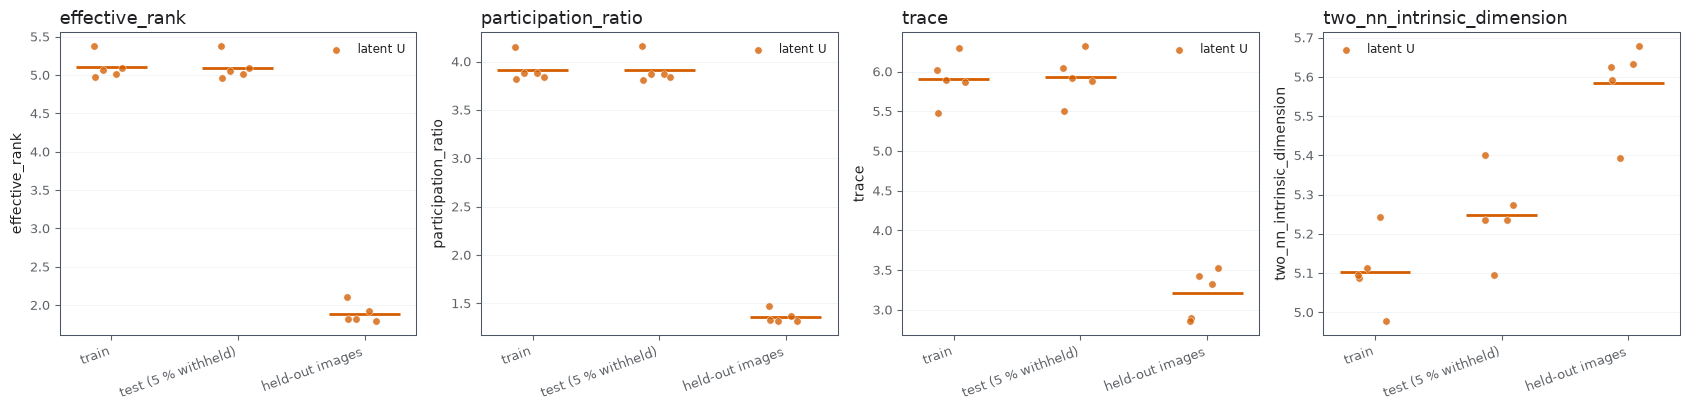

In [3]:
usage = geometry[(geometry.space == 'u') & geometry.metric.isin(['effective_rank', 'participation_ratio', 'trace', 'two_nn_intrinsic_dimension'])]
figure, axes = plt.subplots(1, 4, figsize=(17, 4.2), dpi=theme.figure_dpi)
for ax, metric in zip(axes, ['effective_rank', 'participation_ratio', 'trace', 'two_nn_intrinsic_dimension']):
    figures.repetition_points(usage[usage.metric == metric].assign(space='latent U'), value='value', group='population', hue='space', order=LATENT_POPULATIONS, hue_order=['latent U'], colors={'latent U': LABEL_COLORS[MODEL_LABEL]}, ylabel=metric, title=metric, ax=ax, theme=theme)
figure.tight_layout()
display(usage.pivot_table(index='metric', columns='population', values='value', aggfunc=['mean', 'std'])) 
display(table('data_geometry').drop(columns=['axis'], errors='ignore'))

### Remarks

- Latent effective rank 5.1 and participation ratio 3.9 on train/test (higher than on the narrow axis: 4.6 / 3.4); 1.9 / 1.4 on held-out images; TwoNN 5.1-5.6.
- Input effective rank is 4.0 (train) because the 100-200 window dominates the input variance; input TwoNN 9.4-9.9.

### Notes

## Eigenvalue spectra of latent and input

### Methodology

#### Theoretical

The share of variance per principal direction shows how evenly the latent uses its dimensions and how fast
the input spectrum decays.

#### Implementation

`eigenvalues` (space `u`) and `data_spectrum` (explained variance ratio of the sampled inputs, first 50 components).

#### Figure descriptions

Left: x = latent component, y = share of the latent variance, one line per repetition, colour = population.
Right: x = input principal component (log scale), y = explained variance ratio of the input (log scale).

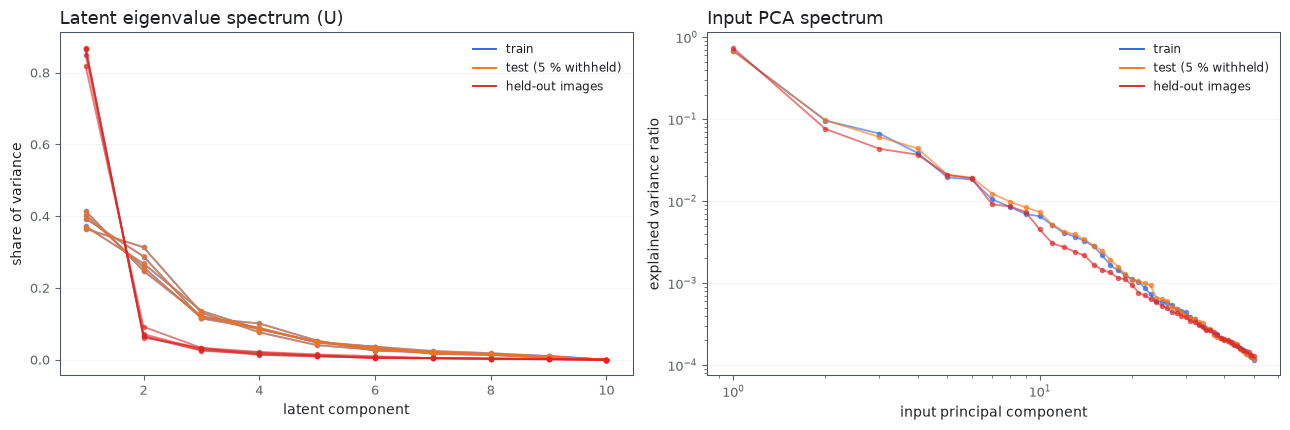

In [4]:
eigen = table('eigenvalues')
eigen = eigen[eigen.space == 'u'].copy()
eigen['share'] = eigen.value / eigen.groupby(['model_id', 'population']).value.transform('sum')
data_spectrum = table('data_spectrum').assign(repetition=0)
figure, axes = plt.subplots(1, 2, figsize=(13, 4.4), dpi=theme.figure_dpi)
figures.line_by_repetition(eigen, x='component', y='share', color_by='population', levels=LATENT_POPULATIONS, colors=POPULATION_COLORS, xlabel='latent component', ylabel='share of variance', title='Latent eigenvalue spectrum (U)', ax=axes[0], theme=theme)
figures.line_by_repetition(data_spectrum, x='component', y='explained_variance_ratio', color_by='population', levels=LATENT_POPULATIONS, colors=POPULATION_COLORS, xlabel='input principal component', ylabel='explained variance ratio', title='Input PCA spectrum', log_x=True, log_y=True, ax=axes[1], theme=theme)
figure.tight_layout()

### Remarks

### Notes

## Angular structure of the latent cloud

### Methodology

#### Theoretical

If the codes were uniformly spread on the sphere, $\cos\theta$ of random pairs would have mean 0 and SD
$\sigma_0 = 1/\sqrt{D-1}$. A narrower or skewed distribution indicates clustering; a distribution shifted to
positive values indicates codes concentrated in one region of the sphere.

#### Implementation

`angular_samples` holds the raw $\cos\theta$ of 5000 random pairs of the shared sample per model and population.

#### Figure descriptions

One panel per population; x = $\cos\theta$, y = density; one step histogram per repetition; dashed curve =
normal approximation of the uniform-sphere null. The table gives observed mean and SD against $\sigma_0$.

mean                           std                
population                    heldout_image    test   train heldout_image    test   train
metric                                                                                   
observed_mean_cos_theta              0.6734  0.4194  0.4271        0.0318  0.0286  0.0294
observed_sd_cos_theta                0.3547  0.3437  0.3453        0.0377  0.0126  0.0122
uniform_baseline_sd_cos_theta        0.3333  0.3333  0.3333        0.0000  0.0000  0.0000

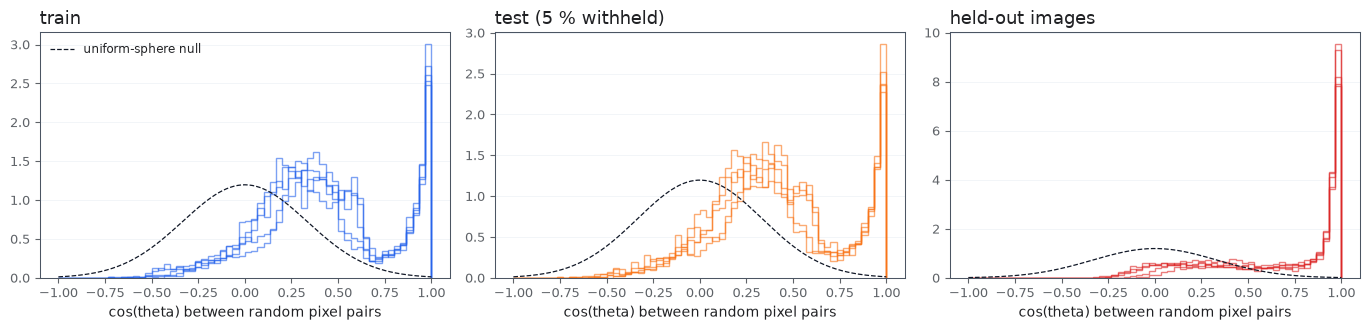

In [5]:
samples = table('angular_samples')
uniform_sd = float(geometry[geometry.metric == 'uniform_baseline_sd_cos_theta'].value.iloc[0])
figures.cos_theta_histograms(samples, populations=LATENT_POPULATIONS, uniform_sd=uniform_sd, theme=theme);
display(geometry[geometry.metric.isin(['observed_mean_cos_theta', 'observed_sd_cos_theta', 'uniform_baseline_sd_cos_theta'])].pivot_table(index='metric', columns='population', values='value', aggfunc=['mean', 'std']))

### Remarks

- Mean cos(theta) 0.42-0.43 (0.67 on held-out), SD close to the uniform null (ratio 1.03-1.06).

### Notes

## Reproducibility of the geometry across repetitions

### Methodology

#### Theoretical

Two repetitions learn the same representation up to rotation when linear CKA is high and the Procrustes
distance low; they preserve the same neighbourhoods when kNN overlap, trustworthiness and continuity are high.

#### Implementation

`reproducibility` holds the battery for every pair of repetitions on the shared test and held-out samples.

#### Figure descriptions

x = population, one point per pair of repetitions per statistic panel, bar = mean.

mean     std     min
statistic           population                           
continuity          heldout_image  0.9981  0.0008  0.9963
                    test           0.9991  0.0002  0.9987
knn_overlap         heldout_image  0.6971  0.0329  0.6449
                    test           0.7866  0.0191  0.7588
linear_cka          heldout_image  0.9965  0.0021  0.9926
                    test           0.9672  0.0097  0.9512
procrustes_distance heldout_image  0.1250  0.0189  0.1036
                    test           0.2236  0.0377  0.1401
trustworthiness     heldout_image  0.9973  0.0017  0.9932
                    test           0.9990  0.0003  0.9985

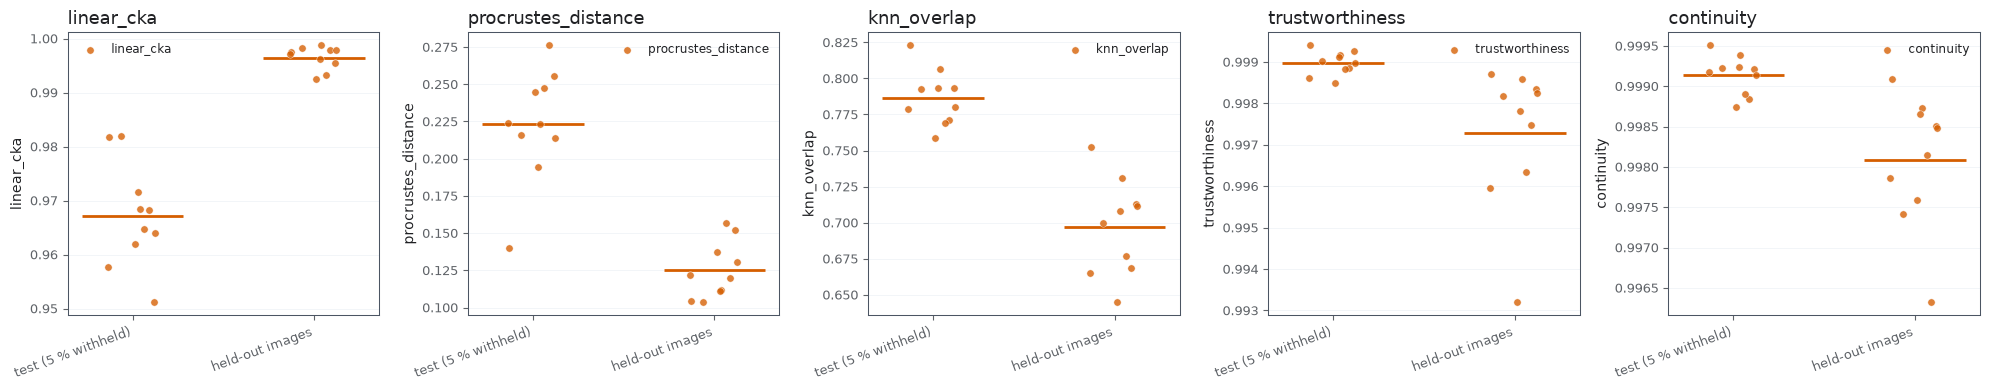

In [6]:
pairs = table('reproducibility')
long = pairs.melt(id_vars=['population', 'left_repetition', 'right_repetition'], value_vars=['linear_cka', 'procrustes_distance', 'knn_overlap', 'trustworthiness', 'continuity'], var_name='statistic', value_name='value')
figure, axes = plt.subplots(1, 5, figsize=(20, 4), dpi=theme.figure_dpi)
for ax, statistic in zip(axes, ['linear_cka', 'procrustes_distance', 'knn_overlap', 'trustworthiness', 'continuity']):
    figures.repetition_points(long[long.statistic == statistic], value='value', group='population', hue='statistic', order=['test', 'heldout_image'], hue_order=[statistic], colors={statistic: LABEL_COLORS[MODEL_LABEL]}, ylabel=statistic, title=statistic, ax=ax, theme=theme)
figure.tight_layout()
display(long.groupby(['statistic', 'population']).value.agg(['mean', 'std', 'min']))

### Remarks

- Linear CKA 0.97 (test) and 0.996 (held-out); kNN overlap 0.79 / 0.70.

### Notes

## Encoder sensitivity to input perturbation

### Methodology

#### Theoretical

$\varepsilon \mapsto \mathbb{E}[\angle(u(x), u(x + \varepsilon \lVert x \rVert \delta))]$ with a random unit
direction $\delta$: the mean angle the code moves under a relative perturbation of size $\varepsilon$.
Lower values mean a smoother (more contractive) encoder; equal curves on test and held-out rows mean the
encoder behaves identically on new images.

#### Implementation

`sensitivity` (from the `inference` level): 1000 fixed rows per population, identical perturbation directions for every model.

#### Figure descriptions

x = $\varepsilon$ (log scale), y = mean angle (degrees); colour = population, one line per repetition.

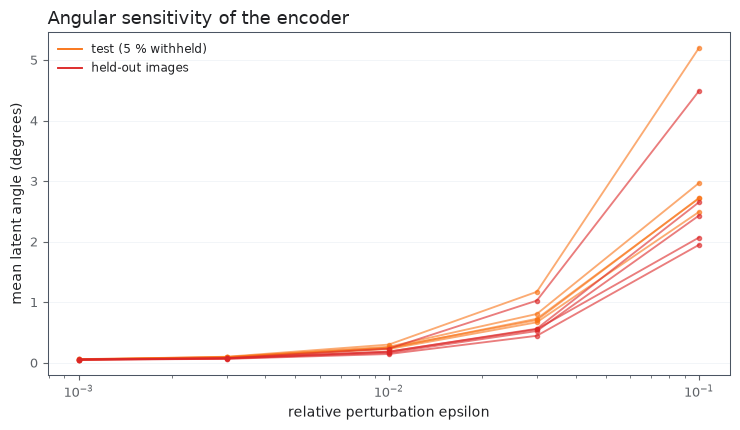

In [7]:
sensitivity = table('sensitivity')
figures.line_by_repetition(sensitivity, x='epsilon', y='mean_angle_degrees', color_by='population', levels=['test', 'heldout_image'], colors=POPULATION_COLORS, xlabel='relative perturbation epsilon', ylabel='mean latent angle (degrees)', title='Angular sensitivity of the encoder', log_x=True, theme=theme);

### Remarks

- Mean angle at epsilon = 0.01 is 0.26 deg (test) and 0.18 deg (held-out): unlike the narrow model, the wide encoder is *less* sensitive on held-out images.

### Notes

## Latent geometry against annotations

### Methodology

#### Theoretical

The Spearman correlation between latent angular distance and annotation (Jaccard) distance of random pixel
pairs measures whether pixels with similar codes carry similar molecules; the mean annotation Jaccard of the
$k = 10$ latent neighbours measures the same locally.

#### Implementation

`geometry` metrics `label_correlation_spearman_r` (space `u`) and `knn_annotation_jaccard` (both spaces).

#### Figure descriptions

x = population, one point per repetition; panels = statistic.

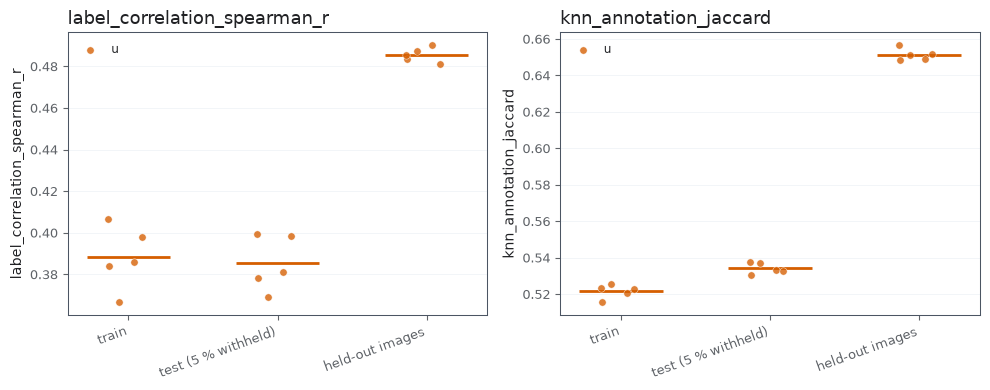

In [8]:
labels = geometry[((geometry.metric == 'label_correlation_spearman_r') & (geometry.space == 'u')) | ((geometry.metric == 'knn_annotation_jaccard') & (geometry.space == 'u'))]
figure, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=theme.figure_dpi)
for ax, metric in zip(axes, ['label_correlation_spearman_r', 'knn_annotation_jaccard']):
    figures.repetition_points(labels[labels.metric == metric], value='value', group='population', hue='space', order=LATENT_POPULATIONS, hue_order=['u'], colors={'u': LABEL_COLORS[MODEL_LABEL]}, ylabel=metric, title=metric, ax=ax, theme=theme)
figure.tight_layout()

### Remarks

- Latent-label correlation 0.39 (0.49 held-out), neighbour Jaccard 0.52-0.53 (0.65 held-out).

### Notes

## Per-dimension distribution shift of the raw codes

### Methodology

#### Theoretical

A distribution shift of new images appears as a displacement of individual latent dimensions. For every
dimension the median on held-out pixels is compared with the training median in units of the training SD.

#### Implementation

`latent_quantiles` holds per model, population and dimension of $Z$ the mean, SD and quantiles.

#### Figure descriptions

Heat map: rows = repetitions, columns = latent dimensions, colour = (median held-out - median train) / SD train.

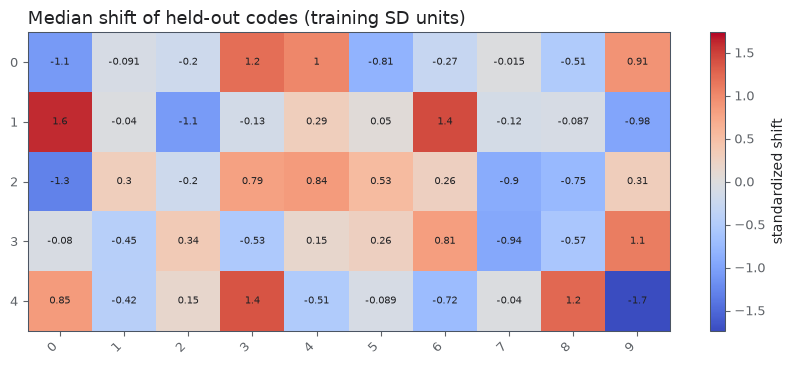

In [9]:
quantiles = table('latent_quantiles')
train = quantiles[quantiles.population == 'train'].set_index(['repetition', 'dimension'])
heldout = quantiles[quantiles.population == 'heldout_image'].set_index(['repetition', 'dimension'])
shift = ((heldout.q50 - train.q50) / train.sd).unstack('dimension')
figures.matrix_heatmap(shift, title='Median shift of held-out codes (training SD units)', colorbar_label='standardized shift', diverging=True, annotate=True, theme=theme);

### Remarks

- Held-out medians shift by 0.52-0.71 training SD on average (maximum 1.7 SD).

### Notes

## Results / Summary

### LLM

- **Observed:** the wide model uses its latent slightly more fully than the narrow one (effective rank 5.1 vs 4.6, trace 5.9 vs 5.2) but is far from saturation (TwoNN about 5 of 8 effective dimensions).
- **Observed:** held-out behaviour mirrors the narrow axis: collapse to effective rank 1.9, a shift of about 0.6 SD per dimension, high reproducibility.
- **Interpretation:** the four-fold wider input does not saturate the ten-dimensional latent; the capacity cost of the wide axis appears in the decoder output (flattened peaks, `part_1_03`) rather than in latent dimension usage.

### Person